### Получаем данные

In [1]:
from src.mlcore.dataloader import get_processed_data

raw = get_processed_data(
    source="raw",
    symbol="BTCUSDC",
    drop_last=True,
    save_dir="parquets/",
    grid_resolution_ms=5000,
)
raw

orderbook_snapshots: 100%|██████████| 3/3 [00:02<00:00,  1.21it/s]


,exchange_ts,open,high,low,close,volume,volume_1s,buy_volume_1s,sell_volume_1s,volume_imbalance_1s,...,ask_qty_90,ask_qty_91,ask_qty_92,ask_qty_93,ask_qty_94,ask_qty_95,ask_qty_96,ask_qty_97,ask_qty_98,ask_qty_99
0,2026-01-23 11:50:30,89139.500000,89139.500000,89130.500000,89130.500000,0.769,0.000,0.0,0.000,0.0,...,0.139,0.450,0.142,0.020,0.182,0.141,0.044,0.114,0.141,0.020
1,2026-01-23 11:50:35,89130.398438,89130.398438,89130.398438,89130.398438,0.002,0.196,0.0,0.196,-1.0,...,0.004,0.139,0.020,0.002,0.139,1.094,0.139,0.177,1.010,1.796
2,2026-01-23 11:50:40,89130.398438,89130.398438,89130.398438,89130.398438,0.002,0.000,0.0,0.000,0.0,...,1.094,0.139,1.122,1.796,0.139,1.002,0.112,1.307,0.179,0.142
3,2026-01-23 11:50:45,89130.398438,89130.398438,89128.000000,89128.101562,0.232,0.000,0.0,0.000,0.0,...,0.168,0.005,0.139,0.415,0.068,0.139,0.004,0.139,0.978,0.139
4,2026-01-23 11:50:50,89128.101562,89128.101562,89128.101562,89128.101562,0.002,0.004,0.0,0.004,-1.0,...,0.150,1.000,0.112,0.141,0.002,0.139,0.005,0.139,0.415,0.003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1970749,2026-05-17 12:59:35,78310.398438,78310.398438,78310.398438,78310.398438,0.001,0.025,0.0,0.025,-1.0,...,0.001,0.129,0.008,0.026,0.002,0.176,0.001,0.174,0.032,0.001
1970750,2026-05-17 12:59:40,78310.398438,78310.398438,78310.398438,78310.398438,0.005,0.000,0.0,0.000,0.0,...,0.281,0.002,0.174,0.001,0.129,0.008,0.026,0.002,0.176,0.001
1970751,2026-05-17 12:59:45,78310.500000,78310.500000,78310.398438,78310.398438,0.006,0.000,0.0,0.000,0.0,...,0.174,0.002,0.050,0.281,0.002,0.174,0.001,0.129,0.008,0.026
1970752,2026-05-17 12:59:50,78310.398438,78310.398438,78310.398438,78310.398438,0.005,0.000,0.0,0.000,0.0,...,0.002,0.050,0.281,0.002,0.174,0.001,0.129,0.008,0.026,0.002


### Определяем таргеты для всех моделей

In [2]:
import numpy as np
import pandas as pd
from tqdm import tqdm


def calculate_mid_target(df: pd.DataFrame):
    target = np.zeros(len(df), dtype=float)
    for i in tqdm(range(len(df) - 1)):
        current = df['close'].iloc[i]
        mid = (df['high'].iloc[i+1] + df['low'].iloc[i+1]) / 2.0
        target[i] = np.log(mid / current)
    return pd.Series(target, index=df.index)


def calculate_spread_target(df: pd.DataFrame):
    target = np.zeros(len(df), dtype=float)
    for i in tqdm(range(len(df) - 1)):
        current = df['close'].iloc[i]
        spread = df['high'].iloc[i+1] - df['low'].iloc[i+1]
        target[i] = spread / current
    return pd.Series(target, index=df.index)


mid_target = calculate_mid_target(raw)
spread_target = calculate_spread_target(raw)

100%|██████████| 1970753/1970753 [00:32<00:00, 60738.74it/s]


### Генерируем фичи для всех моделей

In [3]:
from src.mlcore.dataloader import calculate_features

df = calculate_features(raw, filename='all_features')
df['low'] = raw['low']
df['high'] = raw['high']
df['close'] = raw['close']
df['mid_target'] = mid_target
df['spread_target'] = spread_target
df.dropna(inplace=True)
df

,adverse_selection_risk,ask_price_pressure,atr,atr_exponential_smoothing_alpha_0_8,bid_ask_cancellation_proxy5,bid_ask_spread_tightness_index,bid_price_pressure,combo16_weighted_orderbook_log_times_slope,combo29_response_imbalance_log1p_times_wli,combo35_fqi_rolling_std_18_times_slope,...,volatility_contraction_expansion_ratio,weighted_depth_ratio,weighted_log_imbalance_5levels,weighted_orderbook_imbalance,weighted_price_pressure,low,high,close,mid_target,spread_target
30,2.006901,0.239281,3.200521,3.661918,0.000158,2.007099,0.570680,4.786719,0.792320,46.865198,...,0.149314,4.469285,5.971203,0.945199,0.946031,89142.398438,89150.796875,89145.703125,1.051649e-06,0.000000
31,2.003516,0.108000,3.096962,3.504230,0.000215,2.003678,0.605414,2.926283,0.586270,29.270985,...,0.149314,4.552787,4.290501,0.954427,0.975515,89145.796875,89145.796875,89145.796875,0.000000e+00,0.000000
32,2.156771,0.777938,2.993730,3.274704,0.000290,2.156915,0.081938,1.749922,0.323272,24.258308,...,0.149314,2.923003,2.836123,0.606268,0.605403,89145.796875,89145.796875,89145.796875,0.000000e+00,0.000000
33,2.118490,0.026508,2.893939,3.044951,0.000464,2.118600,0.056250,1.075827,0.175314,20.123774,...,0.145076,2.113305,2.312881,0.400141,0.395230,89145.796875,89145.796875,89145.796875,5.104744e-05,0.000001
34,2.118490,0.026102,2.950860,3.091232,0.001012,2.118575,0.062438,0.838326,0.152370,13.869313,...,0.153596,2.194393,1.794387,0.443673,0.445137,89150.296875,89150.398438,89150.398438,1.962956e-05,0.000039
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1970749,1.626823,0.154172,2.629109,2.067237,0.000282,1.626821,0.219273,-0.365039,-0.207877,-13.397076,...,0.116110,0.556150,-3.509927,-0.069340,-0.113869,78310.398438,78310.398438,78310.398438,0.000000e+00,0.000000
1970750,1.626823,0.110094,2.541472,1.920000,0.000248,1.626821,0.265586,-0.028068,0.014242,-0.495078,...,0.116110,0.917022,0.121679,0.150645,0.119787,78310.398438,78310.398438,78310.398438,6.484609e-07,0.000001
1970751,1.626823,0.155492,2.460142,1.788746,0.000211,1.626821,0.210133,-0.093846,-0.021370,-2.317332,...,0.116110,0.758900,-0.582594,-0.107430,-0.110522,78310.398438,78310.500000,78310.398438,0.000000e+00,0.000000
1970752,1.346875,0.133555,2.378137,1.662156,0.000173,1.346873,0.211656,-0.051334,-0.025191,-2.106525,...,0.098422,0.775421,-0.457865,-0.064828,-0.070871,78310.398438,78310.398438,78310.398438,0.000000e+00,0.000000


In [4]:
feature_columns = [col for col in df.columns if col not in ['mid_target', 'spread_target', 'close', 'high', 'low']]
X = df[feature_columns].copy()
y_mid = df['mid_target'].copy()
y_spread = df['spread_target'].copy()
ohlcv = df[['close', 'high', 'low']].copy()

split_index = int(len(X) * 0.75)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_mid_train, y_mid_test = y_mid.iloc[:split_index], y_mid.iloc[split_index:]
y_spread_train, y_spread_test = y_spread.iloc[:split_index], y_spread.iloc[split_index:]
_, ohlcv_test = ohlcv.iloc[:split_index], ohlcv.iloc[split_index:]

### Обучаем mid model

In [7]:
from src.mlcore.train import train_regression_model

mid_model = train_regression_model(
    X_train=X_train,
    y_train=y_mid_train,
    X_test=X_test,
    y_test=y_mid_test,
    n_estimators=5000,
    objective='reg:squarederror',
    model_name="model_mid",
    max_depth=1,
)

Обучение модели...
[0]	validation_0-rmse:0.00008
[50]	validation_0-rmse:0.00008
[100]	validation_0-rmse:0.00008
[110]	validation_0-rmse:0.00008
Модель сохранена в директорию: models/model_mid.json


MAE                      : 0.000041
RMSE                     : 0.000080
R²                       : 0.059888
MAE / mean|Δ|            : 0.963605
RMSE / RMSE_base         : 0.968399
mean|Δ| (target)         : 0.000043

------------------------------------------------------------
Directional Accuracy     : 0.544738
Target Pos Ratio         : 0.489915
Profit Factor            : 2.502346
Avg Gain (correct)       : 0.000012
Avg Loss (incorrect)     : -0.000006

------------------------------------------------------------
Binomial p-value (vs 50%)     : 0.000000
Directional Acc 95% CI        : (0.5433, 0.5462)
Is Significant (α=5%)         : True

📊 Квантильный анализ (топ-3 квантиля по уверенности):
            quantile  confidence  directional_acc  mean_return  n_samples
(4.17e-05, 4.45e-05]    0.000044         0.970496     0.000126      13727
(1.77e-05, 4.17e-05]    0.000035         0.516290     0.000003      83213
 (9.7e-06, 1.77e-05]    0.000014         0.847311     0.000005      50842


/root/AlgoTradingSystem_c1/src/mlcore/evaluation.py:130: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for q, group in df.groupby('quantile'):


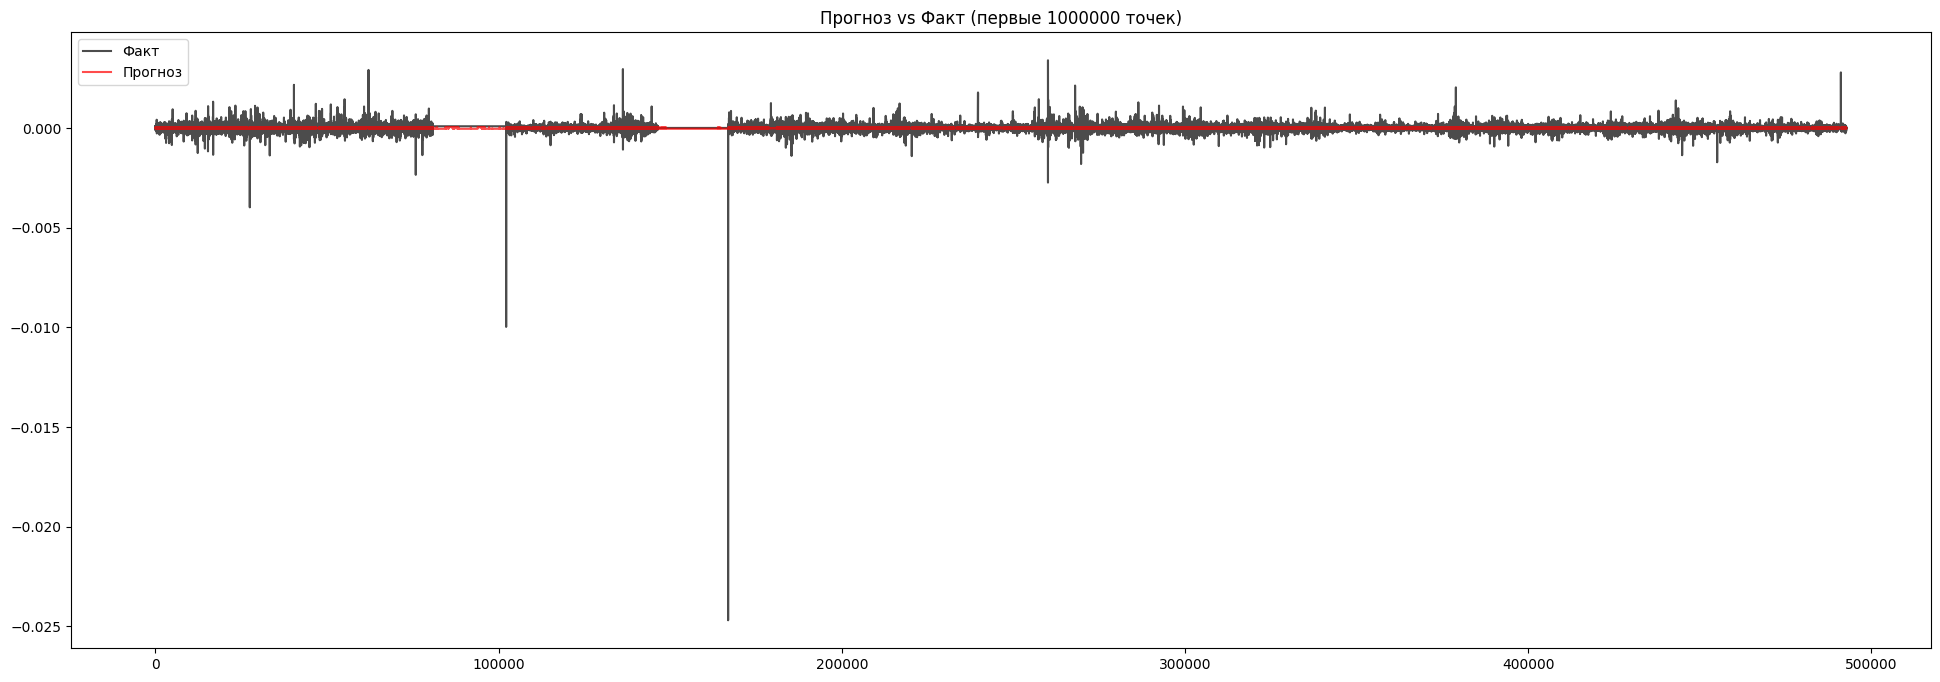

In [8]:
from src.mlcore.evaluation import evaluate_regression_model

y_mid_pred = mid_model.predict(X_test)

evaluate_regression_model(
    y_test=y_mid_test,
    y_pred=y_mid_pred,
    length=1000000,
)

### Обучаем spread model

In [9]:
from src.mlcore.train import train_regression_model

spread_model = train_regression_model(
    X_train=X_train,
    y_train=y_spread_train,
    X_test=X_test,
    y_test=y_spread_test,
    n_estimators=5000,
    objective='reg:squaredlogerror',
    model_name="model_spread",
    max_depth=1,
)

Обучение модели...
[0]	validation_0-rmse:0.00016
[50]	validation_0-rmse:0.00014
[100]	validation_0-rmse:0.00013
[150]	validation_0-rmse:0.00012
[200]	validation_0-rmse:0.00012
[250]	validation_0-rmse:0.00012
[300]	validation_0-rmse:0.00011
[350]	validation_0-rmse:0.00011
[400]	validation_0-rmse:0.00011
[431]	validation_0-rmse:0.00011
Модель сохранена в директорию: models/model_spread.json


MAE                      : 0.000084
RMSE                     : 0.000113
R²                       : 0.228538
MAE / mean|Δ|            : 0.888626
RMSE / RMSE_base         : 0.705378
mean|Δ| (target)         : 0.000095

------------------------------------------------------------
Directional Accuracy     : 0.810157
Target Pos Ratio         : 0.810157
Profit Factor            : 46843284764.544350
Avg Gain (correct)       : 0.000117
Avg Loss (incorrect)     : 0.000000

------------------------------------------------------------
Binomial p-value (vs 50%)     : 0.000000
Directional Acc 95% CI        : (0.8090, 0.8113)
Is Significant (α=5%)         : True

📊 Квантильный анализ (топ-3 квантиля по уверенности):
            quantile  confidence  directional_acc  mean_return  n_samples
 (0.000213, 0.00114]    0.000288         0.998356     0.000275      49268
(0.000164, 0.000213]    0.000182         0.991109     0.000121      49261
(0.000126, 0.000164]    0.000143         0.953362     0.000140    

/root/AlgoTradingSystem_c1/src/mlcore/evaluation.py:130: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for q, group in df.groupby('quantile'):


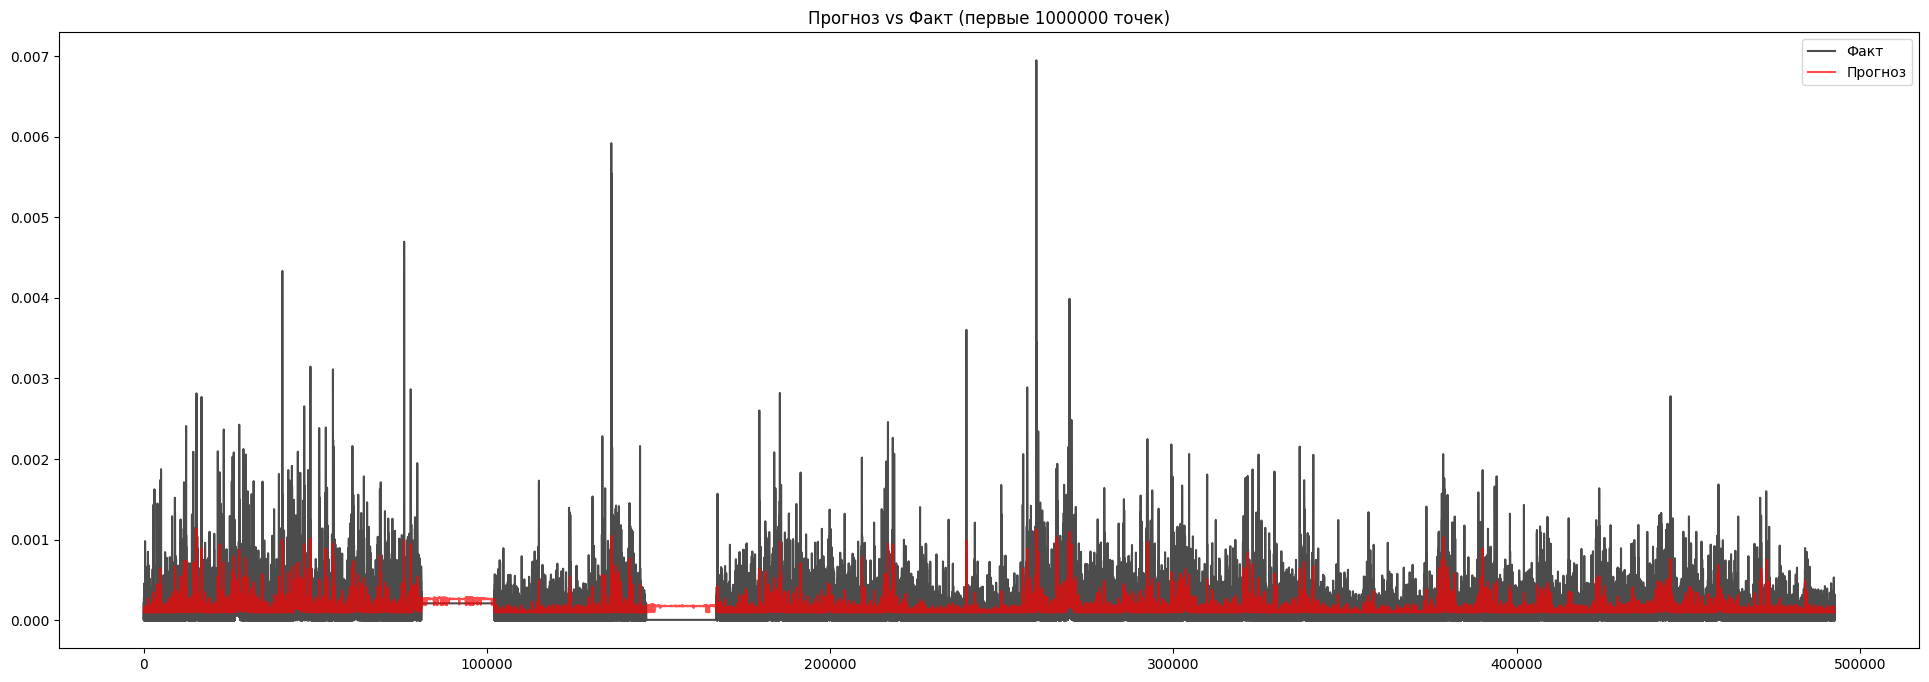

In [10]:
from src.mlcore.evaluation import evaluate_regression_model

y_spread_pred = spread_model.predict(X_test)

evaluate_regression_model(
    y_test=y_spread_test,
    y_pred=y_spread_pred,
    length=1000000,
)